23rd October 2025

##### Prerequisites

In [196]:
layer_name = "d3"

In [197]:
# Import libraries
import numpy as np 
import matplotlib.pyplot as plt
import scipy, pickle
import scipy.signal
from tqdm import tqdm
from scipy import ndimage



In [198]:
# Constants
epsilon = 1e-10

#### Supporting Functions

##### Data extraction

In [199]:
with open('trajectory_results.pkl', 'rb') as f:
    trajectory_results = pickle.load(f)

In [200]:
len(trajectory_results)
print(trajectory_results[0].keys())

dict_keys(['label', 'position', 'pred_position', 'd1', 'z1', 'd2', 'z2', 'd3', 'z3'])


In [201]:
positions = trajectory_results[0]['pred_position']
activations = trajectory_results[0][layer_name]

In [202]:
def get_input_data(activation_path, trajectory_path):
    with open(trajectory_path, 'rb') as f:
        data_pos = pickle.load(f)

    with open(activation_path, 'rb') as f:
        activations = pickle.load(f)

    #data_pos['x'][0],data_pos['x'][0] = -0.7,-0.7
    #x = np.asarray(data_pos['x'])
    #y = np.asarray(data_pos['y'])
    #positions = np.column_stack((x, y))
    return data_pos, activations

##### Plotting functions

In [203]:
def plot_activations_vs_position(activations, positions, layer_name):
    """
    Plots neuron activations against position.

    Parameters
    ----------
    activations : ndarray (time_steps, num_neurons)
        Activations for a given layer.
    positions : ndarray (time_steps, 1)
        Positions corresponding to each activation.
    layer_name : str
        Name of the layer being plotted.
    """

    x_axis = positions[:, 0]

    num_neurons = activations.shape[1]

    num_cols = 5
    num_rows = int(np.ceil(num_neurons / num_cols))

    plt.figure(figsize=(20, 2.5 * num_rows))
    plt.suptitle(f"Amplitude vs Position for Layer: {layer_name}", fontsize=16)

    for neuron_index in range(num_neurons):

        plt.subplot(num_rows, num_cols, neuron_index + 1)

        plt.scatter(
            x_axis,
            activations[:, neuron_index],
            s=2,              # marker size
            alpha=0.4,        # transparency
            color="green"
        )

        plt.xlabel("Position")
        plt.ylabel("Amplitude")
        plt.title(f"Neuron {neuron_index + 1}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [204]:
def plot_frm_vs_position(frm, positions, layer_name, res_param=40):
    """
    Plot firing-rate maps for all neurons.

    Parameters
    ----------
    frm : array-like of shape (num_neurons, num_bins)
        Firing-rate maps returned by get_scores().
    positions : ndarray of shape (num_samples, 1)
        Position data.
    layer_name : str
        Name of layer.
    res_param : int
        Number of spatial bins / 2.
    """

    # Convert list -> ndarray if necessary
    frm = np.asarray(frm)

    # Create x-axis with exactly the same number of bins as frm
    x = np.linspace(
        positions[:, 0].min(),
        positions[:, 0].max(),
        frm.shape[1]
    )

    num_neurons = frm.shape[0]

    num_cols = 5
    num_rows = int(np.ceil(num_neurons / num_cols))

    plt.figure(figsize=(20, 3 * num_rows))
    plt.suptitle(f"Firing Rate vs Position: {layer_name}", fontsize=16)

    for neuron_index in range(num_neurons):

        plt.subplot(num_rows, num_cols, neuron_index + 1)

        plt.plot(x, frm[neuron_index], linewidth=2)

        plt.xlabel("Position")
        plt.ylabel("Firing Rate")
        plt.title(f"Neuron {neuron_index+1}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return x

##### Maps

In [205]:
# Occupancy Map for 1D track - to get position_probability - P(x)

def occupancy_map_func(pos, reso=40, win_len=9):
    '''
    Calculate Occupancy map
    pos: 1D array of positions (track points)
    reso: Resolution for the histogram
    win_len: Window length for the Gaussian filter
    '''

    H1, _ = np.histogram(pos, bins=reso*2)

    gaussian = np.exp(-0.5 * (np.linspace(-3, 3, win_len) ** 2))
    gaussian = gaussian / np.sum(gaussian)

    pos_prob = np.convolve(H1, gaussian, mode='same')
    pos_prob = pos_prob / np.nansum(pos_prob)

    pos_prob[pos_prob == 0] = np.nan

    return pos_prob


In [206]:
def firing_rate_map(resp_neurons, positions, occupancy_map, thresh_param=0.0, title="", ticks_colbar=None, res_param=40, sub_plot=False):
    '''
    Getting Firing rate map from activation and position data, and occupancy map -> No. of spike counts or activation in occupancy time
    '''
    x_positions = positions[:, 0]

    # Computing baseline firing threshold
    mean_resp = np.mean(resp_neurons)
    std_resp = np.std(resp_neurons)
    thresh = mean_resp + (thresh_param * std_resp)

    # Selecting neurons that are firing above the threshold
    firr = np.nonzero(resp_neurons > thresh)
    firposgrid = x_positions[firr[0]]  # Extracting positions of neurons that have fired above the computedthreshold

    # Creating a 1D grid
    x = np.linspace(positions[:,0].min(), positions[:,0].max(), res_param*2)
    firingmap = np.zeros(len(x))

    # Assigning the firing values at the corresponding positions on the track
    firingvalue = resp_neurons[firr]
    for ii in range(len(firposgrid)):
        # Finding the closest grid point on the 1D track using absolute difference
        q1 = np.argmin(np.abs(firposgrid[ii] - x))
        firingmap[q1] = max(firingvalue[ii], firingmap[q1])  # Keep the max firing rate at each position

    # Normalizing the firing map by the occupancy map (time spent in each region)
    if len(occupancy_map) != len(x):
        # Interpolate occupancy map to match the resolution of the firing map
        occupancy_map_interp = np.interp(x, np.linspace(0, 1, len(occupancy_map)), occupancy_map)
    else:
        occupancy_map_interp = occupancy_map

    occupancy_map_interp = np.where(occupancy_map_interp == 0, np.nan, occupancy_map_interp)

    # Normalize firing map by occupancy
    firingmap = firingmap / occupancy_map_interp

    # Applying 1D Gaussian smoothing
    win_len = 9  # Length of Gaussian window
    gaussian = np.exp(-0.5 * (np.linspace(-3, 3, win_len) ** 2))  # 1D Gaussian kernel
    gaussian = gaussian / np.sum(gaussian)  # Normalize the kernel

    # Smoothening the firing map using the Gaussian kernel
    firingmap_smooth = np.convolve(firingmap, gaussian, mode='same')
    firingmap_norm = np.array([1 + (99 * (value - firingmap_smooth.min()) / (firingmap_smooth.max() - firingmap_smooth.min() + epsilon)) for value in firingmap_smooth])
    # Plotting the firing rate map
    if not sub_plot:
        plt.plot(x, firingmap_smooth, label='Firing Rate')
        plt.title(title)
        plt.xlabel('Position along 1D track')
        plt.ylabel('Firing Rate')
        plt.colorbar(ticks=ticks_colbar)
        plt.show()

    return firingmap_smooth, firingmap_norm, firposgrid


##### Scores

In [207]:
def inf_rate(rate_map, px):
    '''
    Calculating spatial information rate - bytes/ spike
    rate_map: firing rate map
    px: occupancy map
    '''
    tmp_map = np.ma.array(rate_map, copy=True)
    tmp_map[np.isnan(tmp_map)] = 0
    avg_rate = np.sum(np.ravel(tmp_map * px))

    #return (np.nansum(np.ravel(tmp_map * np.log2(tmp_map/avg_rate) * px)),
    #        avg_rate)

    return (np.nansum(np.ravel((tmp_map/avg_rate) * np.log2(np.maximum(tmp_map/avg_rate, epsilon)) * px)),
            avg_rate)

In [208]:
def sparsity_func(pos_prob, firing_rate):
    '''
    Calculating sparsity for a given firing rate map

    input:
    pos_prob: probability matrix for position - from occupancy map
    firing_rate: rate map

    output: sparsity from the paper
    '''
    px = np.copy(pos_prob)
    pos_prob2 = px/(np.nansum(px) + epsilon)

    avg_rate = np.nansum(np.ravel(firing_rate * pos_prob2))
    numerator = avg_rate ** 2
    denominator = np.nansum(np.multiply(pos_prob2, firing_rate**2)) + epsilon
    return numerator/denominator

In [209]:
def get_scores(positions, activations):
    '''
    Calculating sparsity,  spatial information rate and spatial score
    '''

    global lim, reso
    sparsity_scores = []
    spatial_info = []
    occupancy_map = occupancy_map_func(positions)
    num_neurons = activations.shape[1]
    fpg_allN = []
    fm_allN = []
    for i in range(num_neurons):
        resp_neurons = activations[:, i]

        fr_map, fr_norm, firposgrid = firing_rate_map(resp_neurons, positions, occupancy_map=occupancy_map, thresh_param=lim, res_param = reso, sub_plot=True)
        fm_allN.append(fr_norm)
        fpg_allN.append(firposgrid)
        # Calculating spatial info
        sp_info_rate, avg_rate = inf_rate(fr_map, occupancy_map)
        #spatial_information = sp_info_rate*0.1/avg_rate
        spatial_information = sp_info_rate/avg_rate
        if np.ma.is_masked(spatial_information):
            spatial_information = 0  # Replace masked value with 0 or any other default value you prefer
        else:
            spatial_information = round(spatial_information,2)
        spatial_info.append(spatial_information)


        # Calculating sparsity scores
        sparsity_score = sparsity_func(occupancy_map, fr_map)
        if np.ma.is_masked(sparsity_score):
            sparsity_score = 0  # Replace masked value with 0 or any other default value you prefer
        else:
            sparsity_score = round(sparsity_score,2)
        sparsity_scores.append(sparsity_score)

    return spatial_info, sparsity_scores, fpg_allN, fm_allN

##### Extracting place cells

In [210]:
def plot_frm_vs_position_together(frm, positions, place_cells, layer_name):
    """
    Plot firing rate maps of all detected place cells on the same figure.

    Parameters
    ----------
    frm : array-like (num_neurons, num_bins)
        Firing rate maps returned by get_scores().
    positions : ndarray (num_samples, 1)
        Position data.
    place_cells : list or ndarray
        Indices of detected place cells.
    layer_name : str
        Name of the layer.
    """

    # Convert to numpy array if necessary
    frm = np.asarray(frm)

    # X-axis corresponding to spatial bins
    x = np.linspace(
        positions[:, 0].min(),
        positions[:, 0].max(),
        frm.shape[1]
    )

    # Sort place cells by the location of their firing peak
    sorted_place_cells = sorted(
        place_cells,
        key=lambda idx: np.argmax(frm[idx])
    )

    plt.figure(figsize=(10, 6))

    for neuron_index in sorted_place_cells:
        plt.plot(
            x,
            frm[neuron_index],
            linewidth=2,
            label=f"Neuron {neuron_index + 1}"
        )

    plt.xlabel("Position")
    plt.ylabel("Normalized Firing Rate")
    plt.title(f"Detected Place Cells - {layer_name}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [211]:
def identify_place_cells(
    spatial_info,
    sparsity_scores,
    positions,
    activations,
    spi_threshold=0.3,
    spar_threshold=0.1
):
    selected_neus_spainfo = np.where(np.asarray(spatial_info) > spi_threshold)[0]
    selected_neus_spars = np.where(np.asarray(sparsity_scores) < spar_threshold)[0]

    selected_neus = list(set(selected_neus_spars) & set(selected_neus_spainfo))
    return selected_neus


In [212]:
def get_scores_by_place_cells(place_cells, spatial_info, sparsity_scores):
    '''
    Extracts spatial information and sparsity scores for identified place cells.

    Args:
        place_cells (list): A list of indices representing the identified place cells.
        spatial_info (list): A list of spatial information scores for all neurons.
        sparsity_scores (list): A list of sparsity scores for all neurons.

    Returns:
        dict: A dictionary containing the place cell indices, spatial information scores,
              and sparsity scores for the selected place cells.
    '''

    place_cells_indices = []
    place_cells_spatial = []
    place_cells_sparsity = []

    for i in place_cells:
        place_cells_indices.append(i)  # Corrected indexing
        place_cells_spatial.append(spatial_info[i])  # Corrected indexing
        place_cells_sparsity.append(sparsity_scores[i])  # Corrected indexing

    pc_dict = {
        'place_cells_indices': place_cells_indices,
        'spatial_info': place_cells_spatial,
        'sparsity_scores': place_cells_sparsity
    }

    return pc_dict


### Identifying place cells

#### Input data extraction

In [213]:

trajectory_result = "trajectory_results.pkl"

all_positions = []
all_activations = []

for traj in trajectory_results:

    pos = traj["pred_position"]
    act = traj[layer_name]

    pos = pos.reshape(-1, 1)
    act = act.reshape(-1, act.shape[-1])

    all_positions.append(pos)
    all_activations.append(act)

#loaded in just one trajectory result, but we can load in all of them and concatenate them together to get a larger dataset for training the classifier.
"""positions = trajectory_results[0]['pred_position']
activations = trajectory_results[0]['z2']

positions = positions.reshape(-1, 1)
activations = activations.reshape(-1, activations.shape[-1])"""

positions = np.concatenate(all_positions, axis=0)
activations = np.concatenate(all_activations, axis=0)

print(positions.shape)
print(activations.shape)
print(activations.dtype)

(5432, 1)
(5432, 50)
complex64


In [214]:
epsilon = 1e-10
reso = 40
lim = 1.8

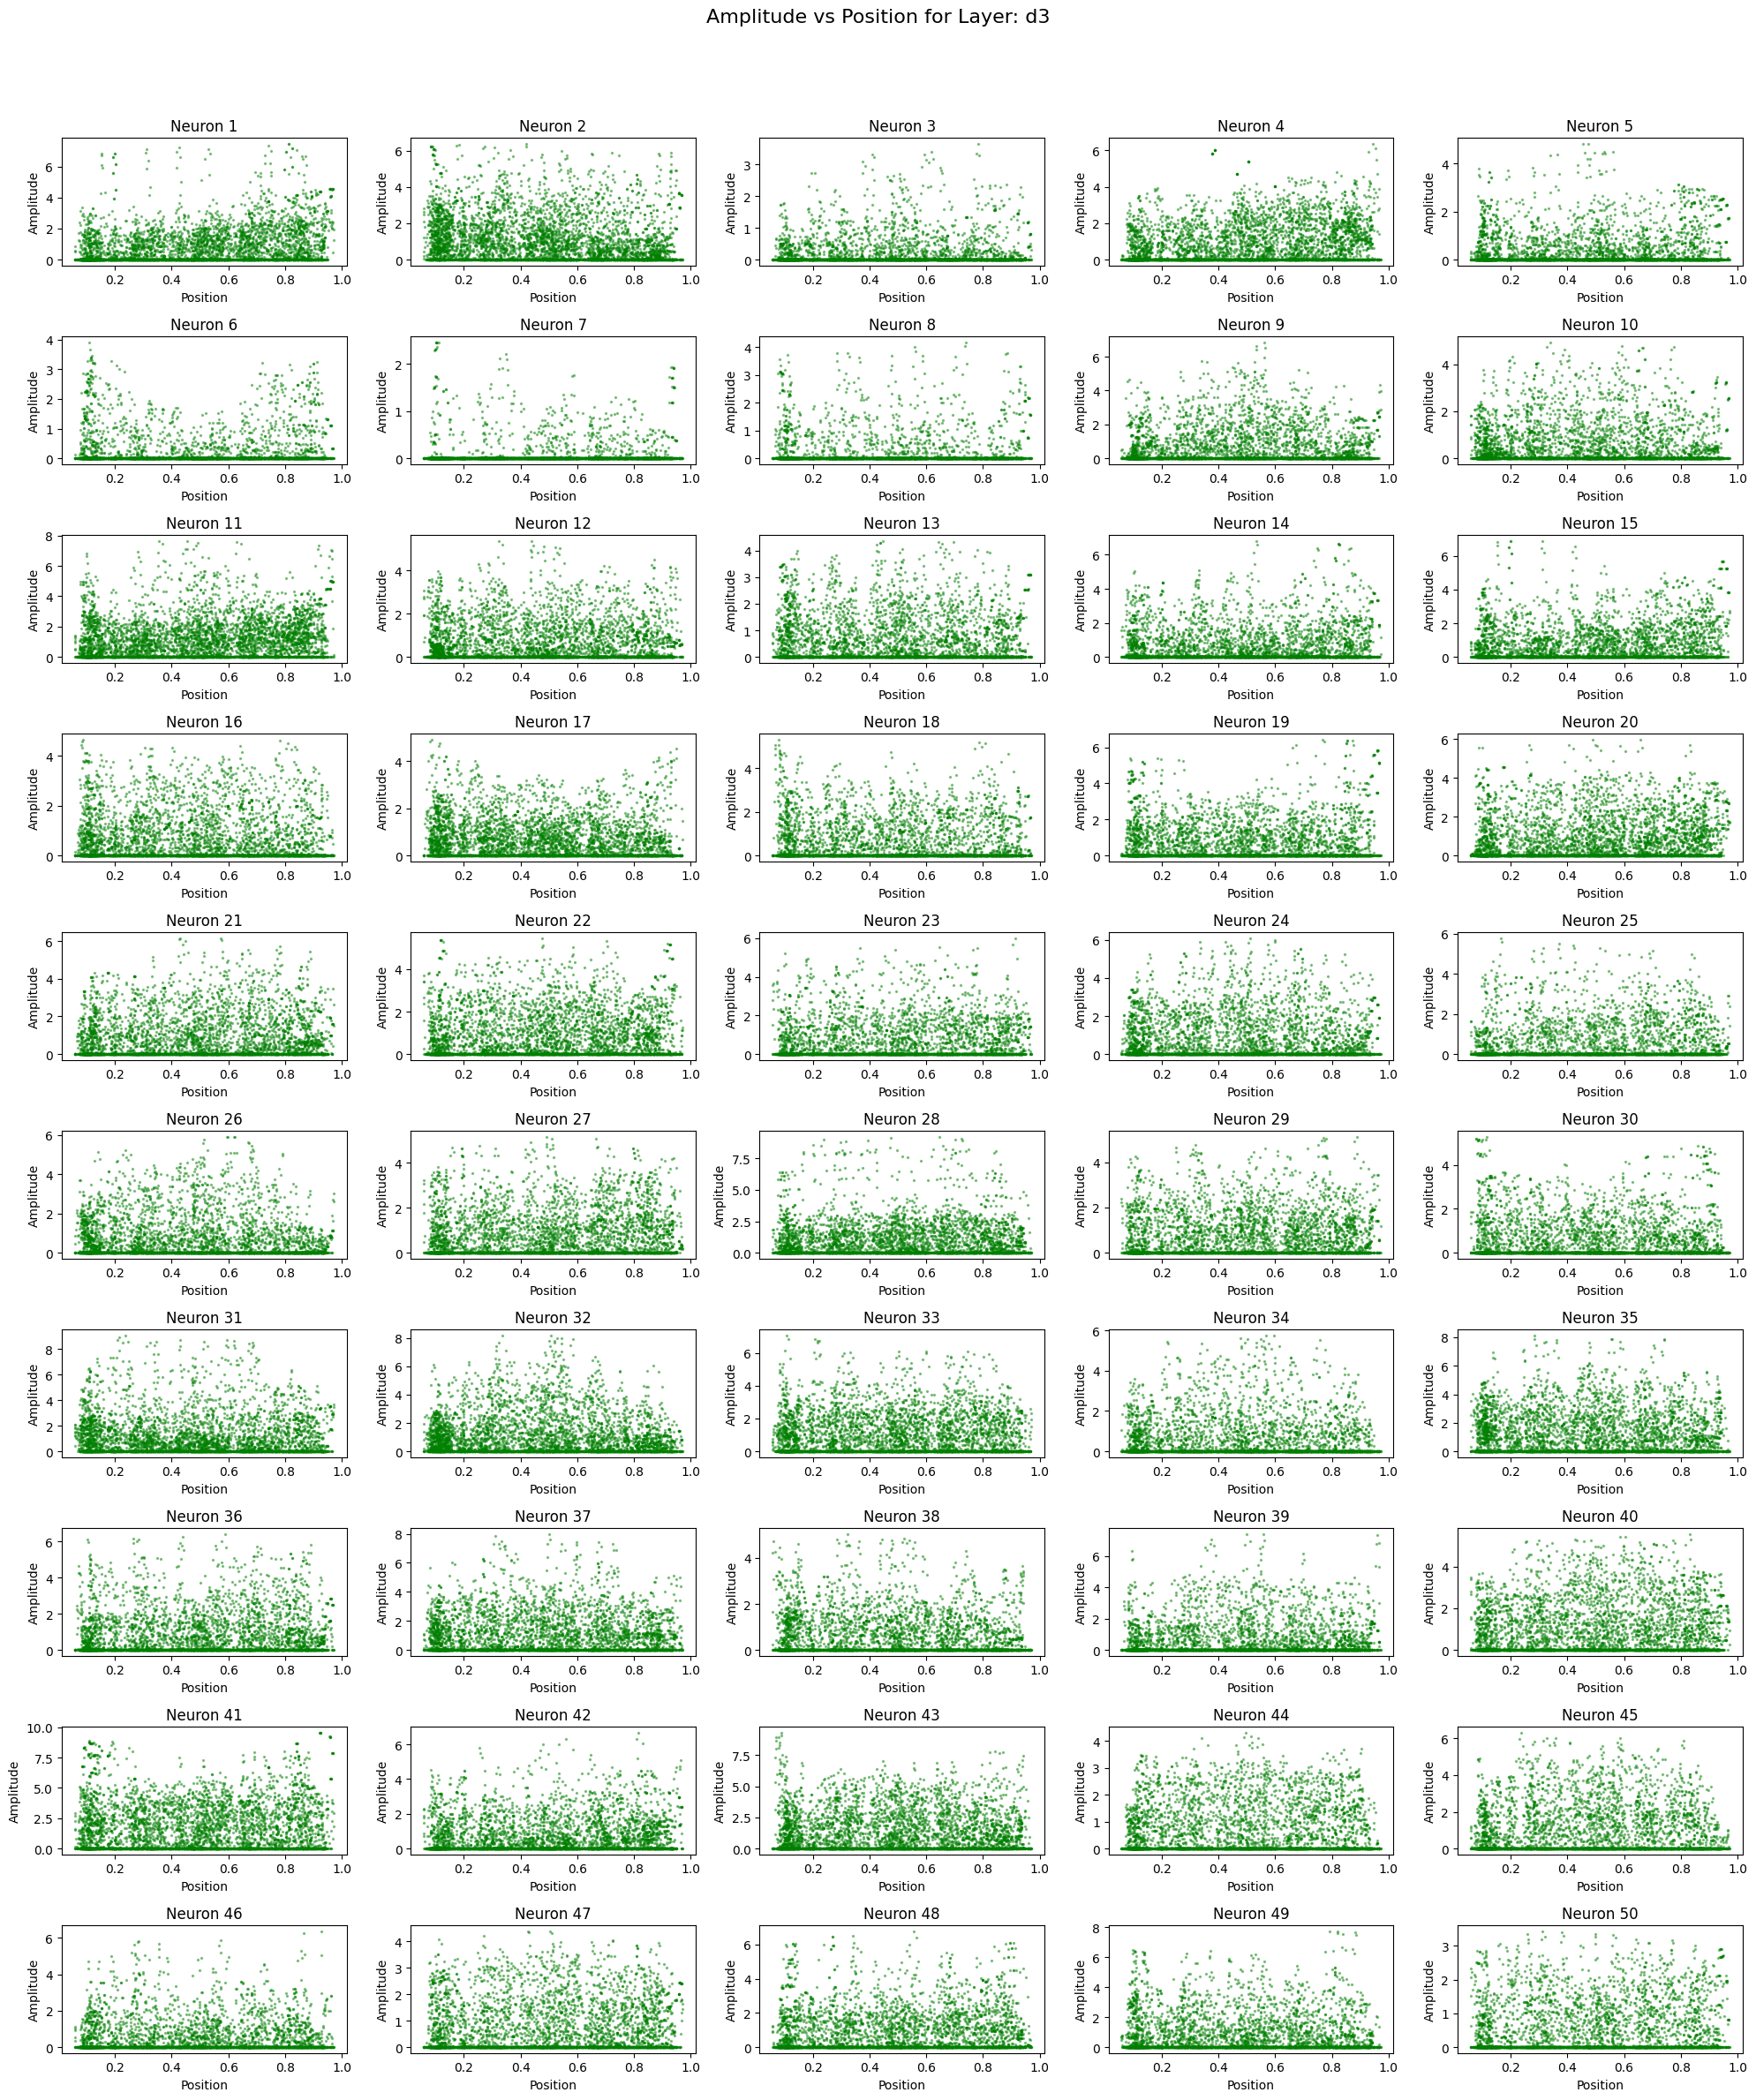

In [215]:
plot_activations_vs_position(
    activations,
    positions,
    layer_name=layer_name
)

In [216]:
spatial_info, sparsity_scores, fpgrid, frm = get_scores(
    positions,
    activations
)

frm = np.asarray(frm)

print("FRM:", frm.shape)

/var/folders/wj/5j3twf2d2t73f60tspzghv400000gn/T/ipykernel_16816/2066397473.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  firingmap[q1] = max(firingvalue[ii], firingmap[q1])  # Keep the max firing rate at each position


FRM: (50, 80)


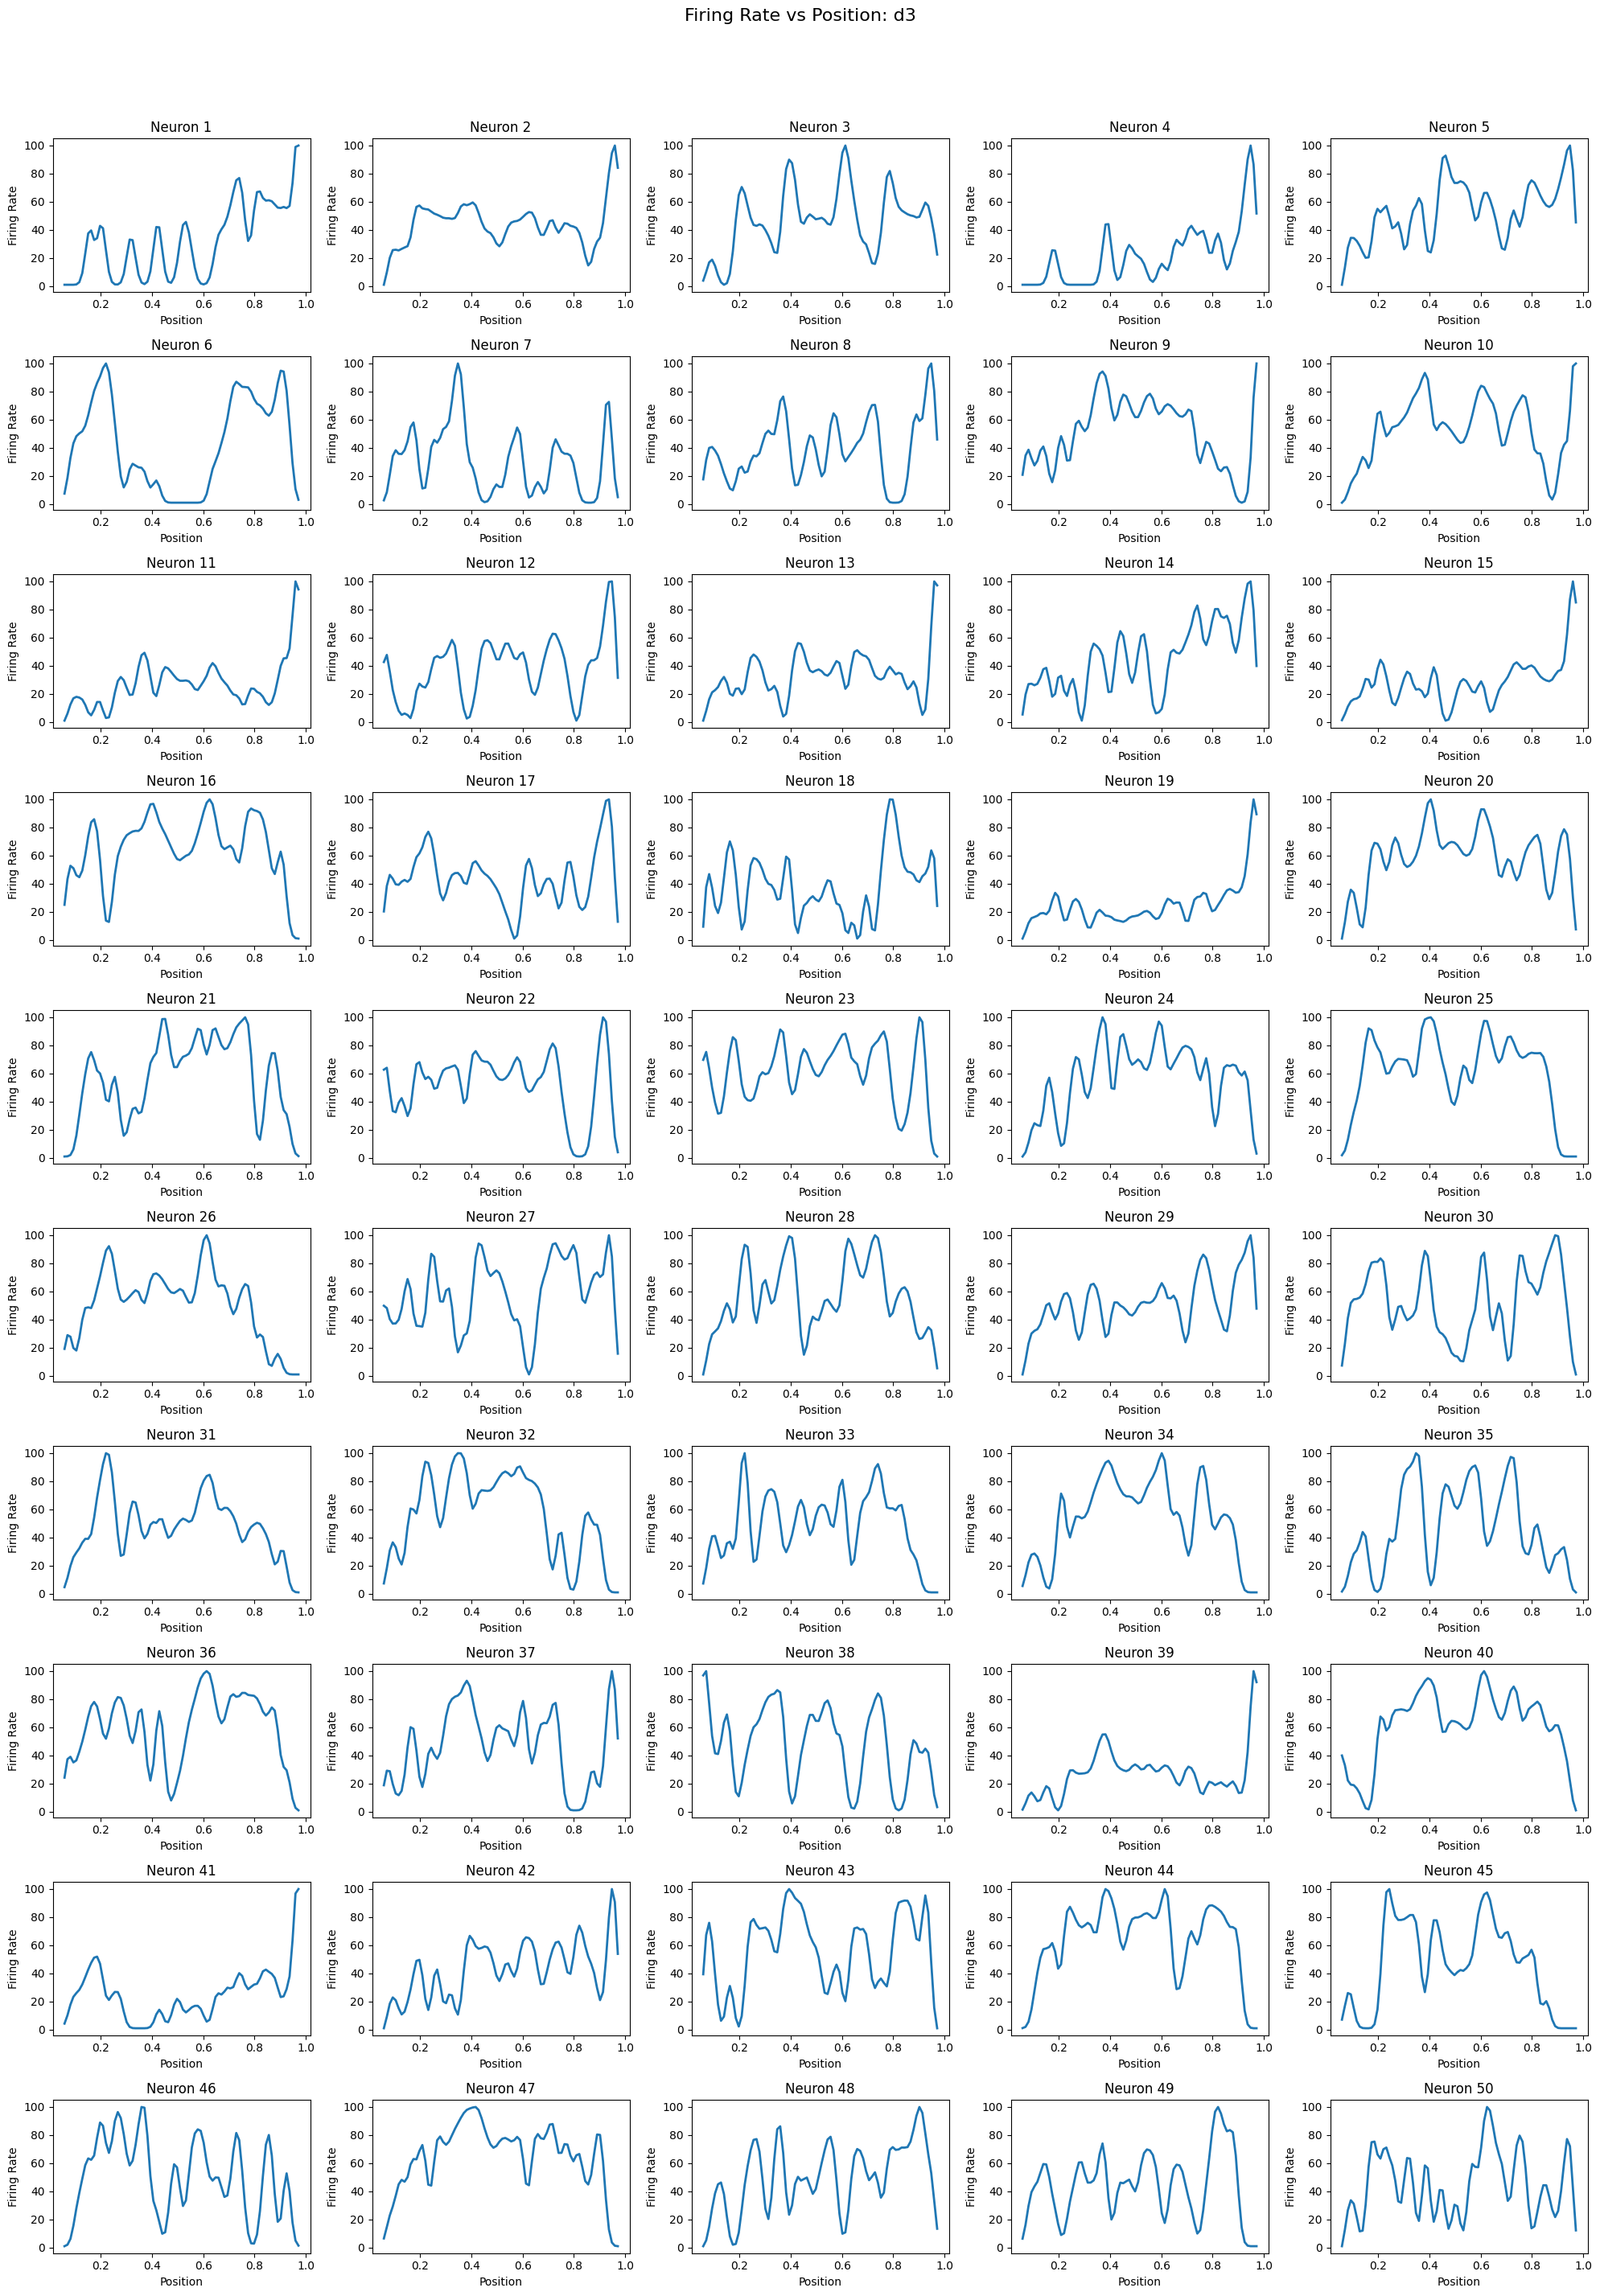

In [217]:
position_bins = plot_frm_vs_position(
    frm,
    positions,
    layer_name=layer_name,
    res_param=20
)

In [218]:
place_cells = identify_place_cells(
    spatial_info,
    sparsity_scores,
    positions,
    activations,
    spi_threshold=0.3,
    spar_threshold=0.12
)

print(place_cells)
print("Number of place cells:", len(place_cells))

[]
Number of place cells: 0


In [219]:
place_cell_dict = get_scores_by_place_cells(
    place_cells,
    spatial_info,
    sparsity_scores
)

for key, value in place_cell_dict.items():
    print(key)
    print(value)
    print("-"*50)

place_cells_indices
[]
--------------------------------------------------
spatial_info
[]
--------------------------------------------------
sparsity_scores
[]
--------------------------------------------------


/var/folders/wj/5j3twf2d2t73f60tspzghv400000gn/T/ipykernel_16816/909490275.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


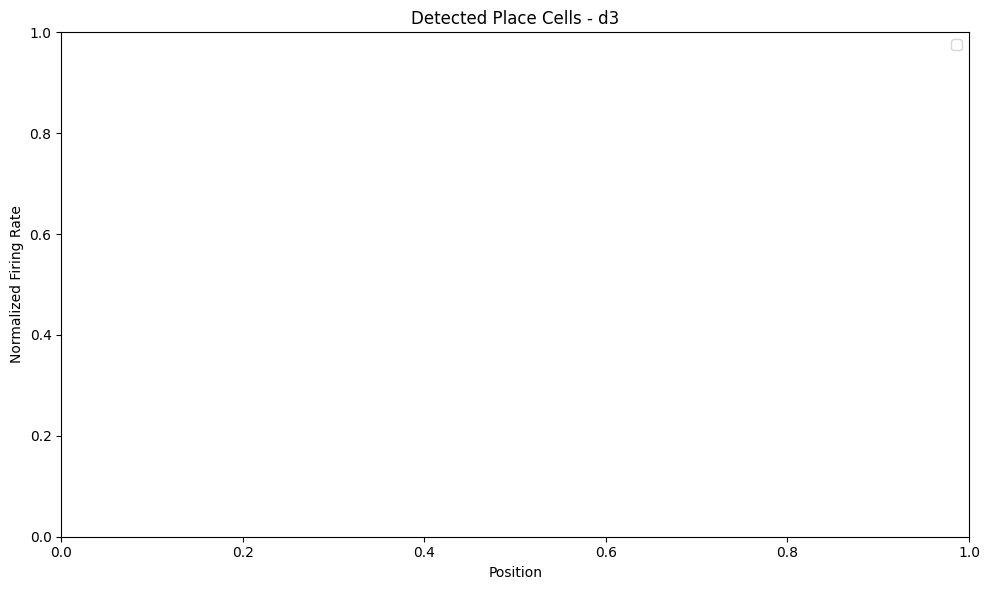

In [220]:
plot_frm_vs_position_together(
    frm,
    positions,
    place_cells,
    layer_name
)

In [221]:
# ----------------------------
# Layer Summary
# ----------------------------

total_neurons = activations.shape[1]
num_place_cells = len(place_cells)
percentage = (num_place_cells / total_neurons) * 100

print("=" * 50)
print(f"Layer: {layer_name}")
print("=" * 50)

print("\nThresholds")
print("----------")
print("lim = 1.8")
print("Spatial Information > 0.30")
print("Sparsity < 0.12")

print("\nDetected Place Cells")
print("-" * 20)
print(f"{num_place_cells} / {total_neurons} neurons ({percentage:.1f}%)")

print("\nIndices")
print("-" * 7)
print(place_cells)

print("\nStatistics")
print("-" * 10)
print(f"Maximum Spatial Information : {np.max(spatial_info):.3f}")
print(f"Mean Spatial Information    : {np.mean(spatial_info):.3f}")
print(f"Maximum Sparsity            : {np.max(sparsity_scores):.3f}")
print(f"Minimum Sparsity            : {np.min(sparsity_scores):.3f}")
print(f"Mean Sparsity               : {np.mean(sparsity_scores):.3f}")

if num_place_cells > 0:
    print("\nDetected Place Cell Scores")
    print("-" * 27)
    for idx in place_cells:
        print(
            f"Neuron {idx+1:2d} | "
            f"Spatial Info = {spatial_info[idx]:.3f} | "
            f"Sparsity = {sparsity_scores[idx]:.3f}"
        )

print("=" * 50)

Layer: d3

Thresholds
----------
lim = 1.8
Spatial Information > 0.30
Sparsity < 0.12

Detected Place Cells
--------------------
0 / 50 neurons (0.0%)

Indices
-------
[]

Statistics
----------
Maximum Spatial Information : 0.010
Mean Spatial Information    : 0.000
Maximum Sparsity            : 0.920
Minimum Sparsity            : 0.480
Mean Sparsity               : 0.817
